In [1]:
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)
print("Environment ready")

Environment ready


Loading the Dataset and overviewing it...

In [2]:
df = pd.read_csv("IBM-HR-Employee-Attrition.csv")
print(df.shape)
print("---------------------------")
print(df.columns)
print("--------------------------------------------")
print(df.info())
print("--------------------------------------------")
print(df.describe().T)
print("----------------------------------------------")
print(df.head())


(1470, 35)
---------------------------
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
--------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    -------------

Data Quality assesment ...

In [3]:
print(df.nunique())
print("-------------------------------------------------")
print(df.describe(include="object"))
print("------------------------------------")
print(df.dtypes)
print("-------------------------------------------------")
print(df.isnull().sum())
print("------------------------------------------------------------")
print(f"The total duplicated vaules in this dataset is: {df.duplicated().sum()}")

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

Now from the above observation we can see that: 
1. There is no null value in this dataset, which is a very good point. 
2. There is no duplicated value in this dataset, its also a very good point signifying the quality of this dataset. So there is no need of deduplication...
3. From this dataset we can see that there are total 26 numerical columns and 9 catagorical columns..
4. From this dataset we can observe one thing that , ther's 3 columns (EmployeeCount, Over18, StandardHours) which have only one unique value. Meaning all the datas in these columns are same. So these columns have no significance on the dataset. We can easily remove these columns and it won't have any effect on the dataset...

In [4]:
#Understanding features and the Target...
cat_cols = df.select_dtypes(exclude=np.number).columns
print(cat_cols)
print("---------------------------------------------------------")
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)
print("-----------------------------------------------------------")
df["Attrition"].value_counts()

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')
---------------------------------------------------------
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
-----------------------------------------------------------


Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
#Dropping consant columns....
df.drop(columns=[
    "EmployeeCount",
    "Over18",
    "StandardHours"
], inplace=True)


Target Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Target Distribution (%):
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


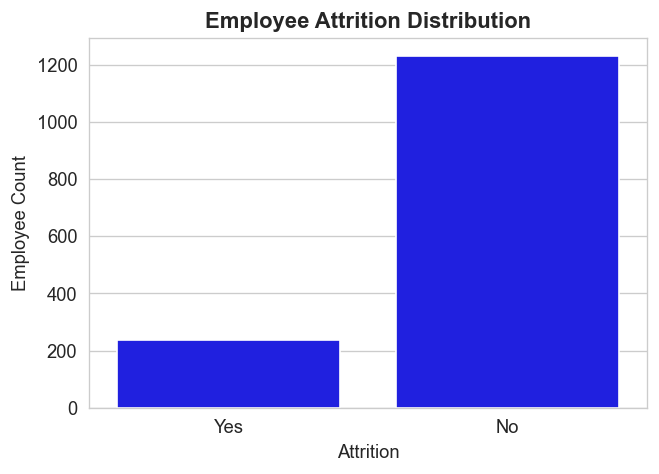

In [6]:
# ==========================================
# 1. Target Variable Analysis
# ==========================================

print("Target Distribution:")
print(df["Attrition"].value_counts())
print()

print("Target Distribution (%):")
print(round(df["Attrition"].value_counts(normalize=True)*100,2))

#visualization..
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition",
    
    color="Blue"
)

plt.title("Employee Attrition Distribution", fontweight="bold")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.savefig("Target Column distribution.png", bbox_inches="tight")

plt.show()

From this visualziation we can see that the target column is slightly imbalanced..
and The employee attrition rate is very low which is a good point....

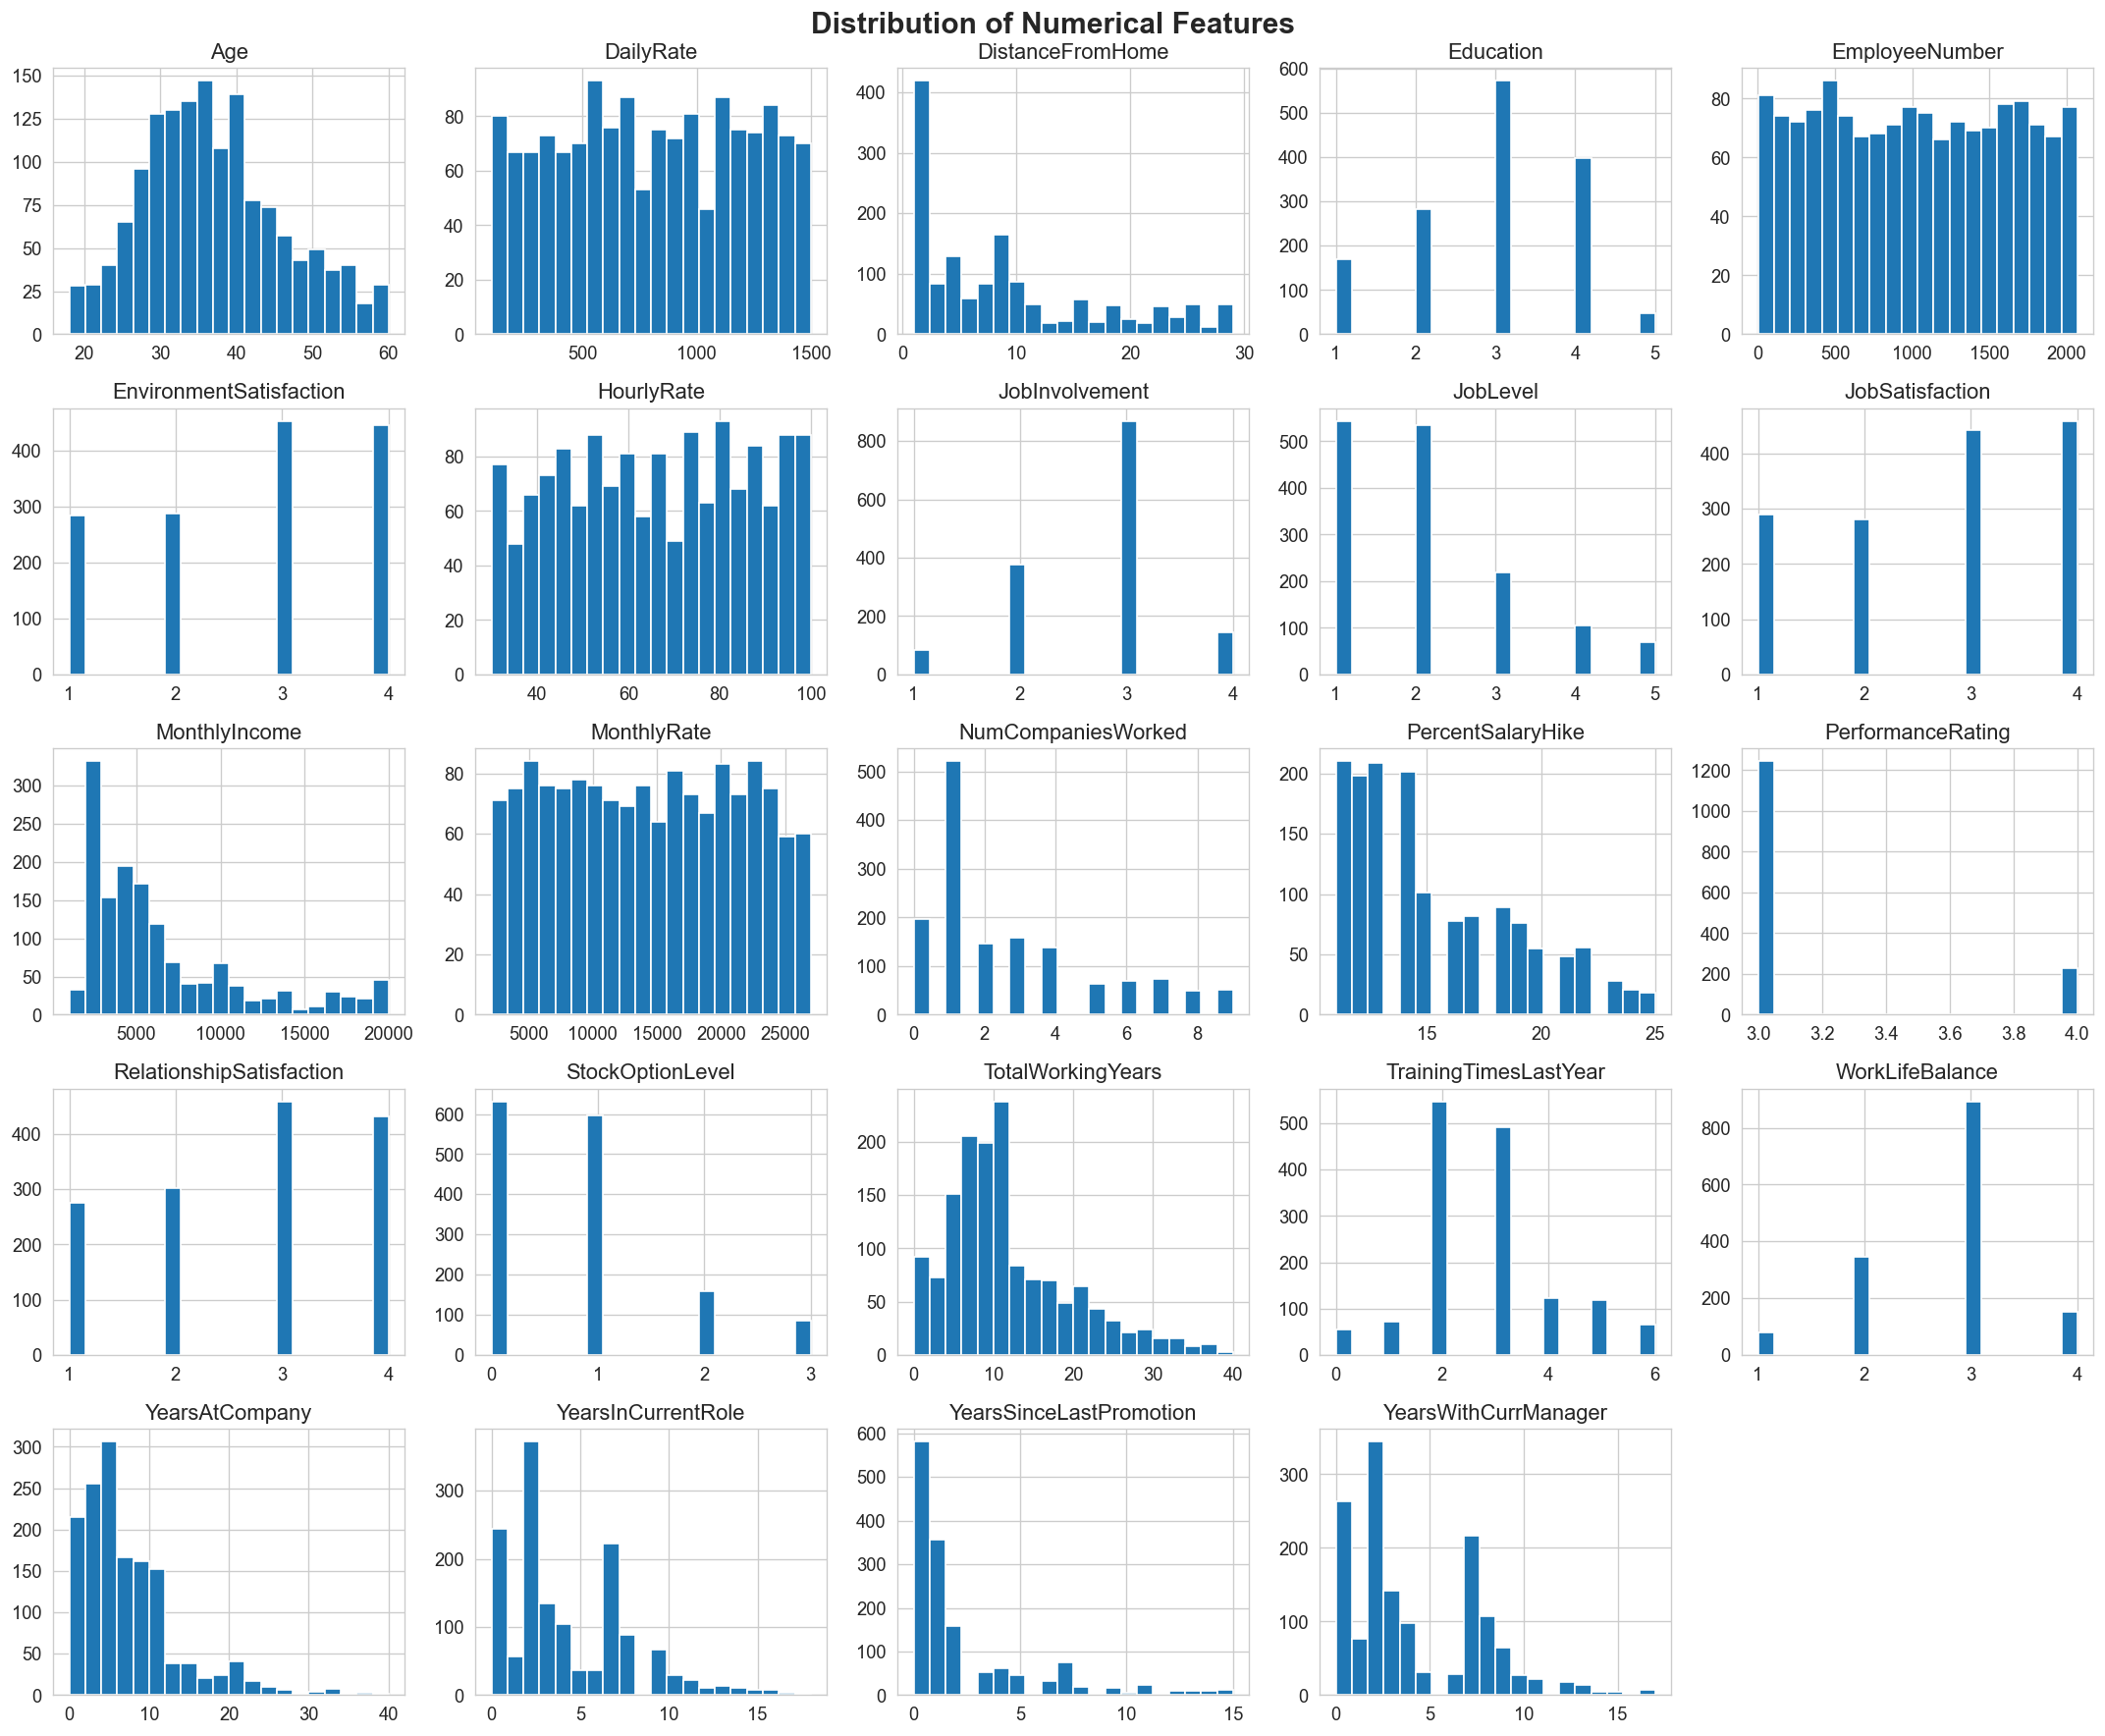

In [7]:
#Neumerical feature distribution...
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(
    figsize=(18,15),
    bins=20
)

plt.suptitle("Distribution of Numerical Features",
             fontsize=18,
             fontweight="bold",

              )
plt.savefig("Numerical Features .png", bbox_inches="tight")

plt.tight_layout()

plt.show()

Here are some of the columns which seems to have most outlires..

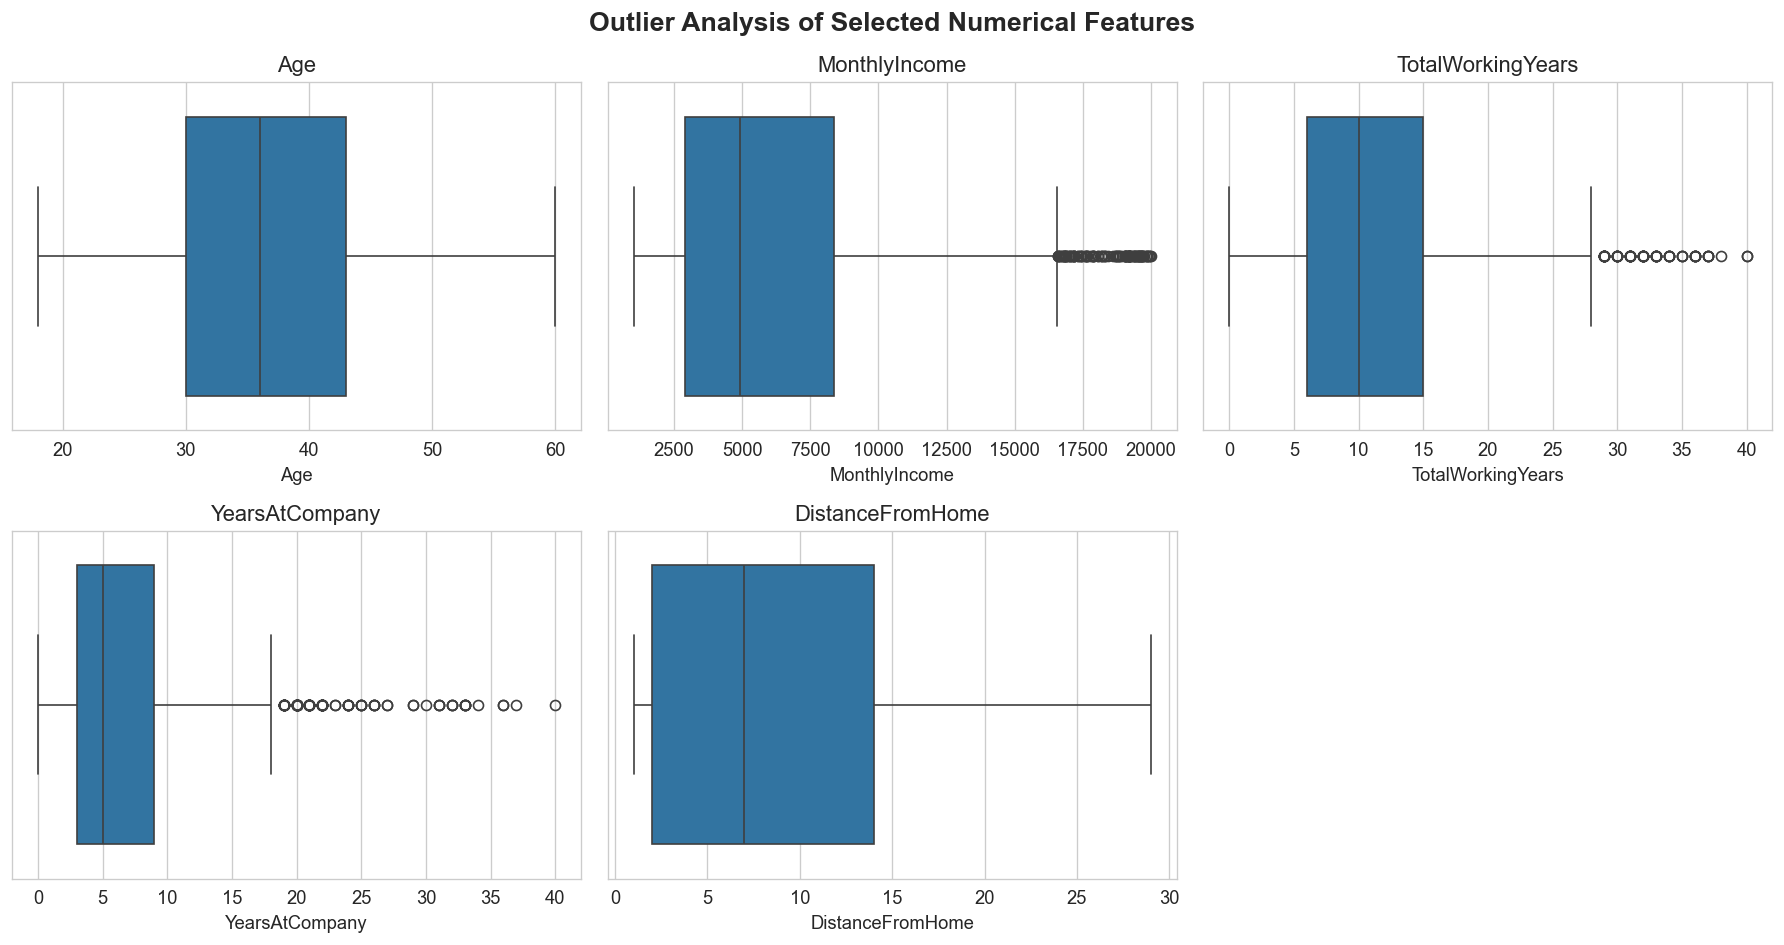

In [8]:
selected_num = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "DistanceFromHome"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, selected_num):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

# Hide unused subplot(s)
for i in range(len(selected_num), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Outlier Analysis of Selected Numerical Features", fontsize=16, fontweight="bold")
plt.savefig("Outlier Analysis.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

From anlaysis of the dataset, here are some of the most important Catagorical  features of the datset... 

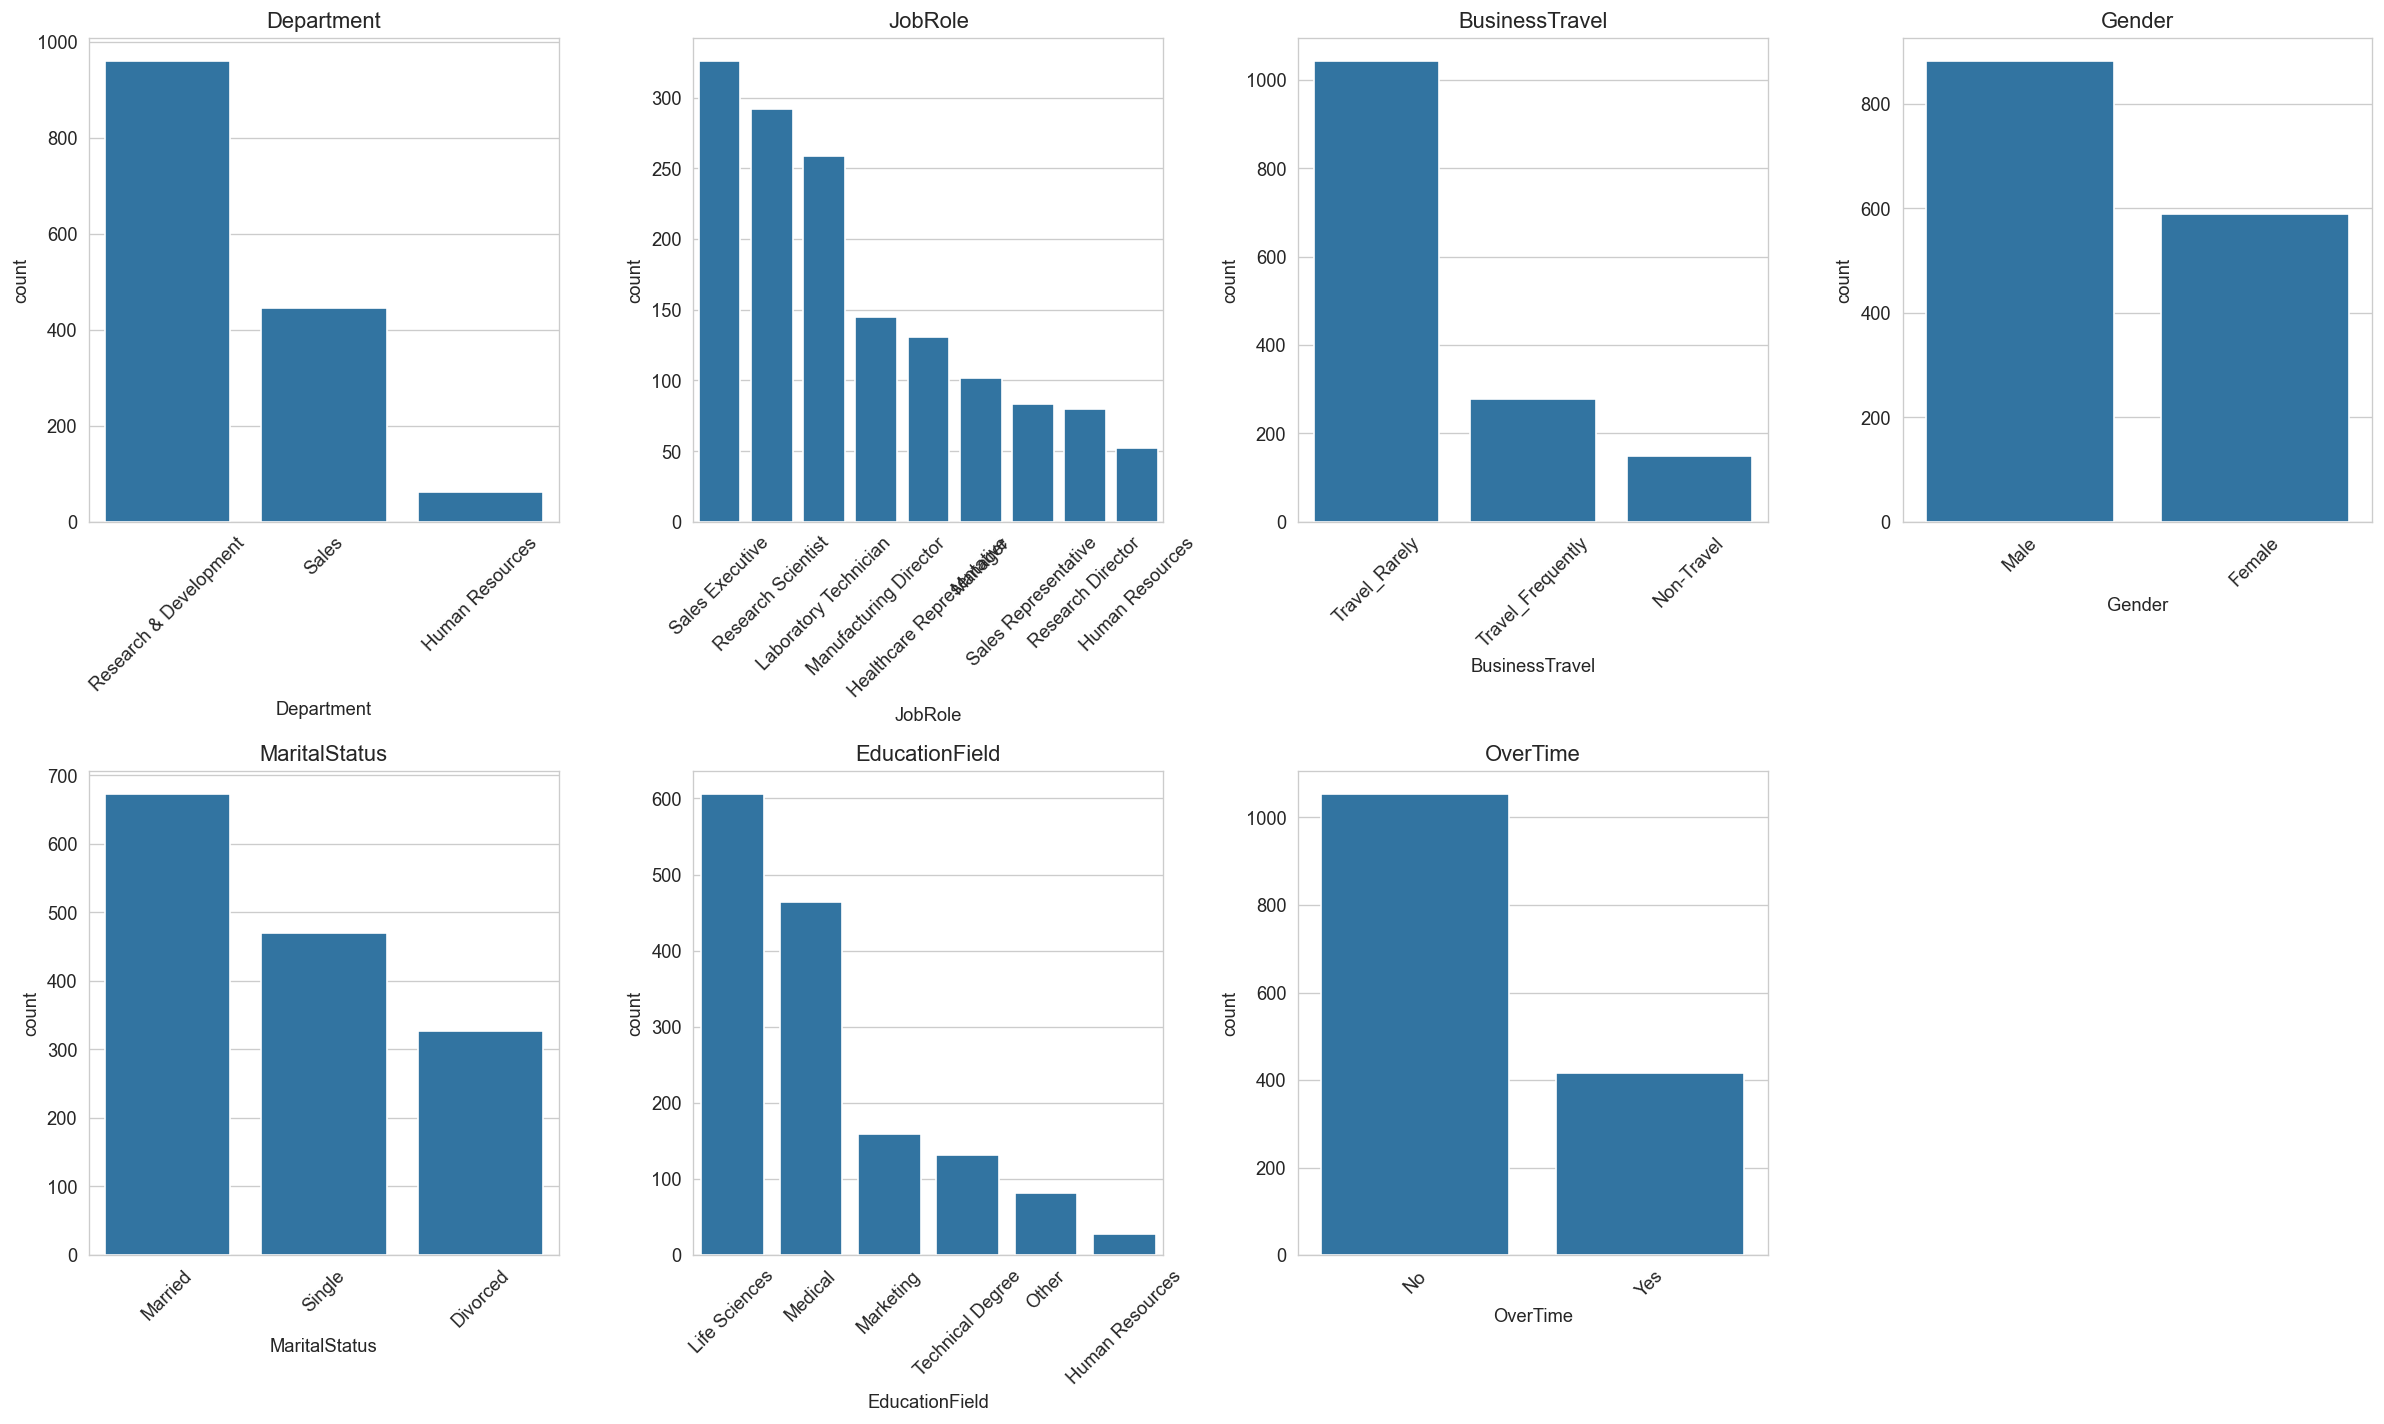

In [9]:
#catagorical feature analysis...
cat_cols = df.select_dtypes(exclude="number").columns
selected_cat = [
    "Department",
    "JobRole",
    "BusinessTravel",
    "Gender",
    "MaritalStatus",
    "EducationField",
    "OverTime"
]
fig, axes = plt.subplots(2,4, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, selected_cat):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for i in range(len(selected_cat), len(axes)):
    axes[i].set_visible(False)
plt.savefig("Catagorical Features.png", bbox_inches="tight")

plt.tight_layout()
plt.show()

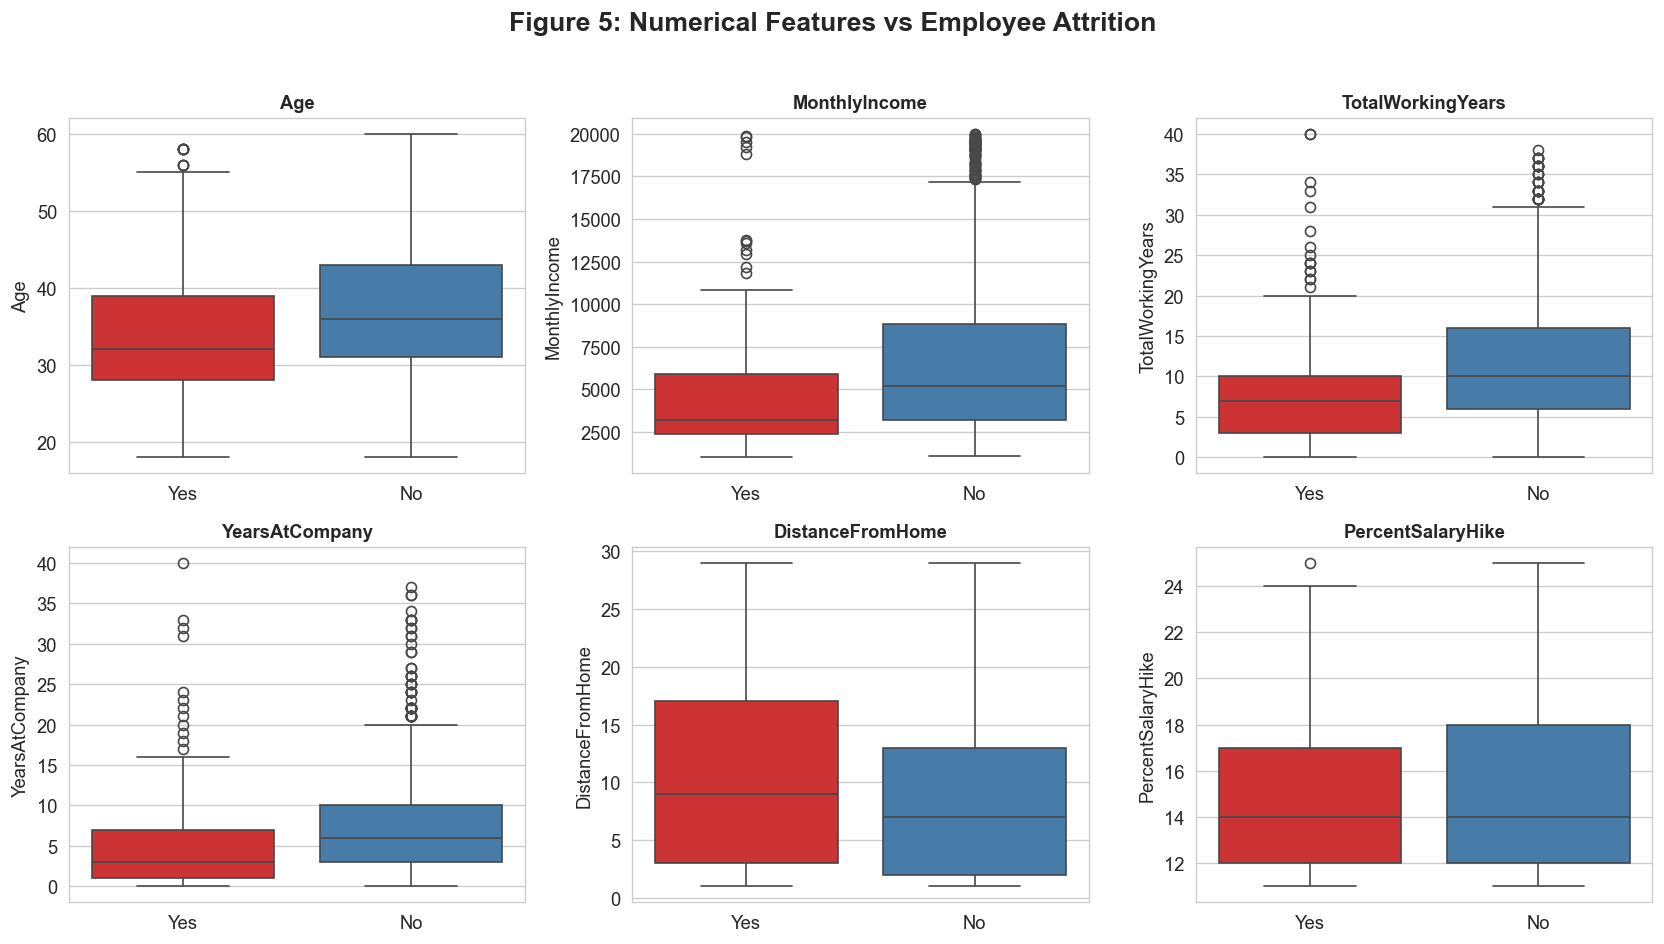

In [10]:
# ==========================================
# Figure 5 : Numerical Features vs Attrition
# ==========================================

selected_num = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "DistanceFromHome",
    "PercentSalaryHike"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, selected_num):

    sns.boxplot(
        data=df,
        x="Attrition",
        y=col,
        ax=ax,
        palette="Set1"
    )

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(col)

# Hide unused axes
for i in range(len(selected_num), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Figure 5: Numerical Features vs Employee Attrition",
    fontsize=16,
    fontweight="bold"
)
plt.savefig("Numerical Features vs Employee Attrition.png", bbox_inches="tight")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

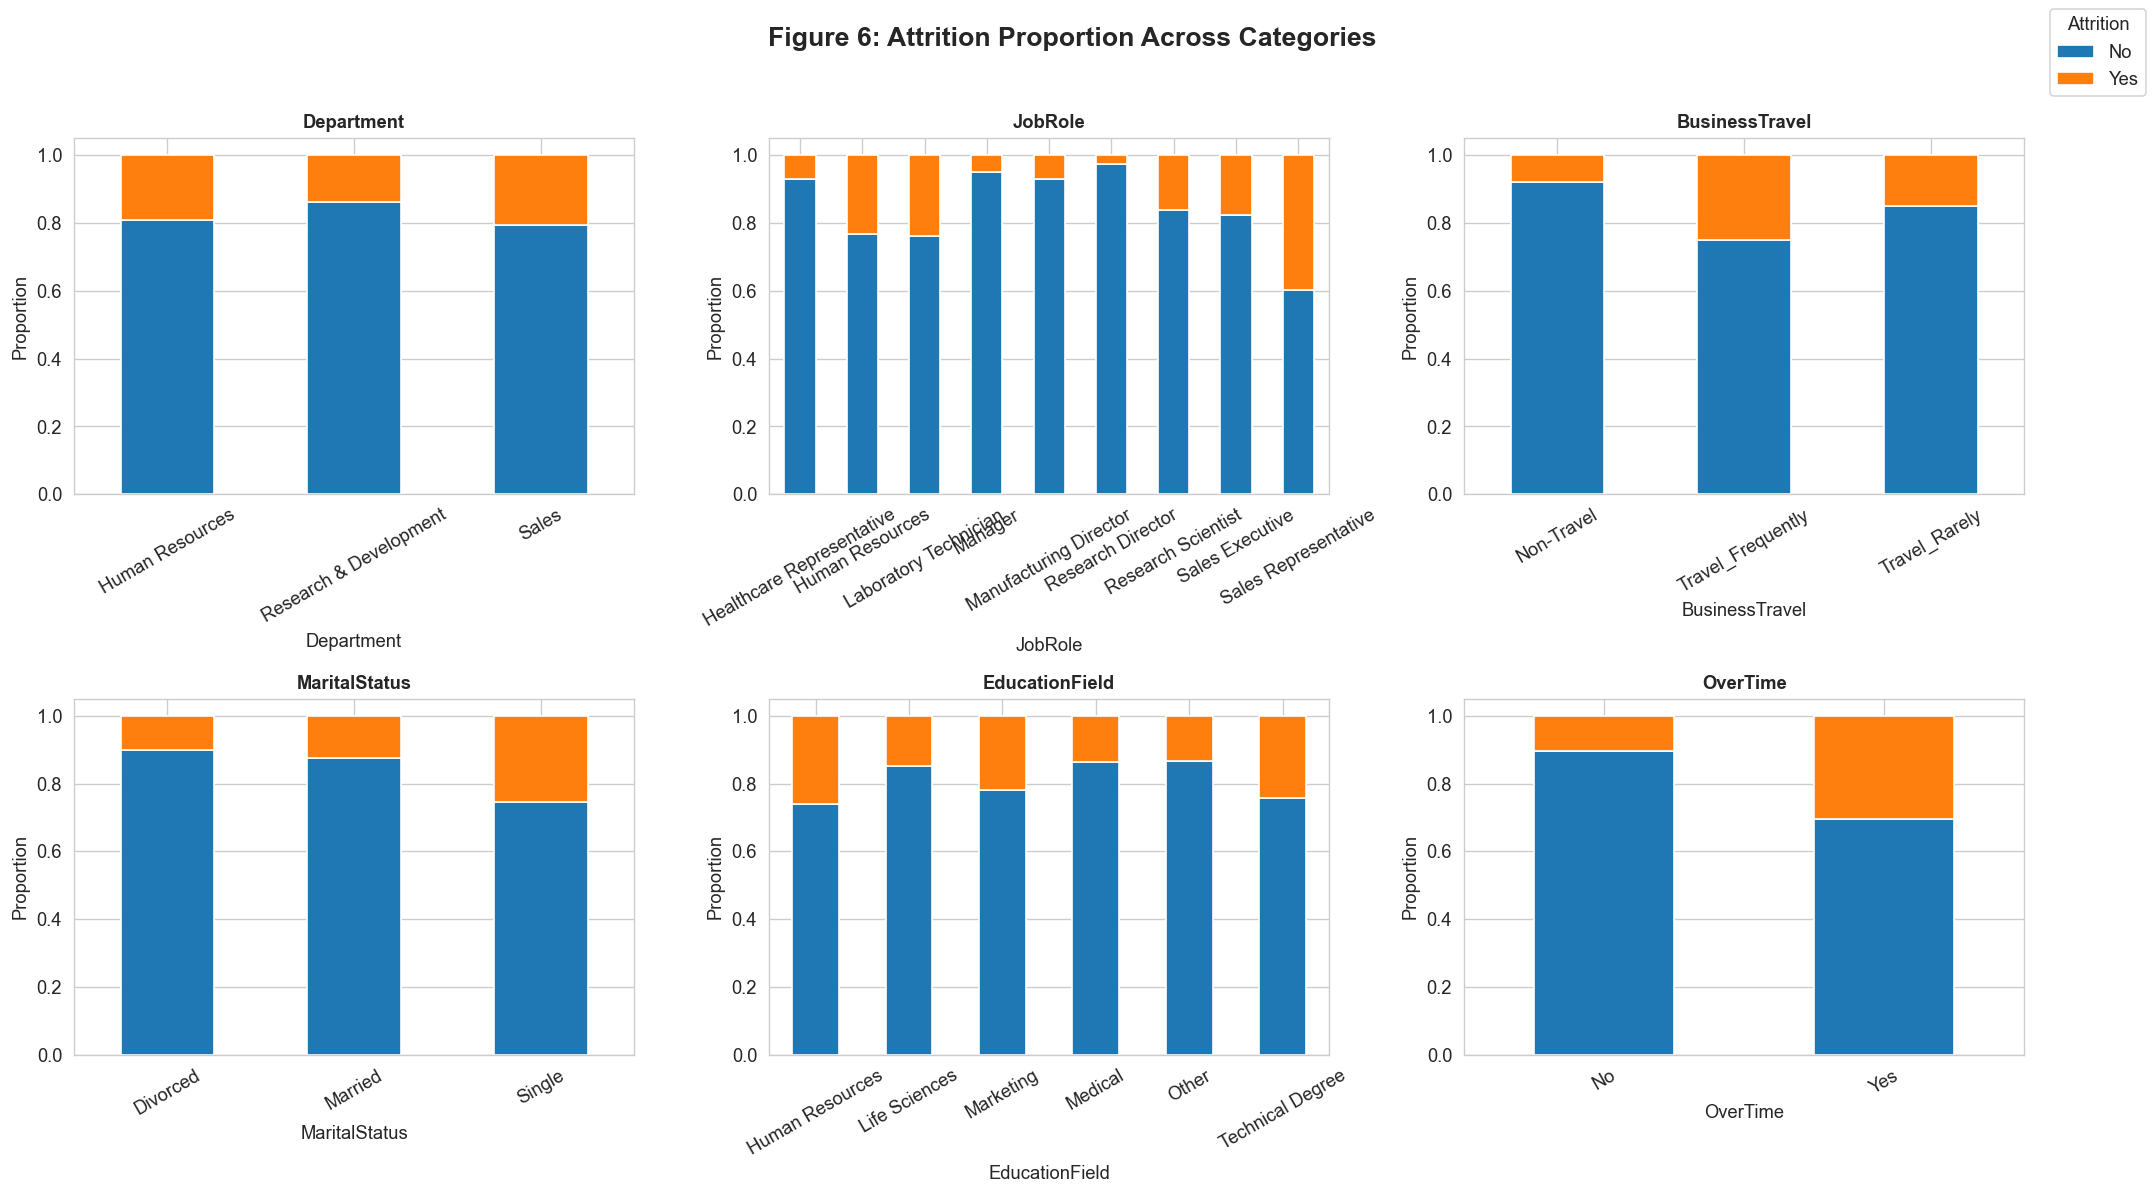

In [11]:
# ==========================================
# Figure 6 : Normalized Categorical vs Attrition
# ==========================================

selected_cat = [
    "Department",
    "JobRole",
    "BusinessTravel",
    "MaritalStatus",
    "EducationField",
    "OverTime"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, selected_cat):

    prop = pd.crosstab(
        df[col],
        df["Attrition"],
        normalize="index"
    )

    prop.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel("Proportion")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Attrition", loc="upper right")

plt.suptitle(
    "Figure 6: Attrition Proportion Across Categories",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,0.95,0.96])
plt.show()

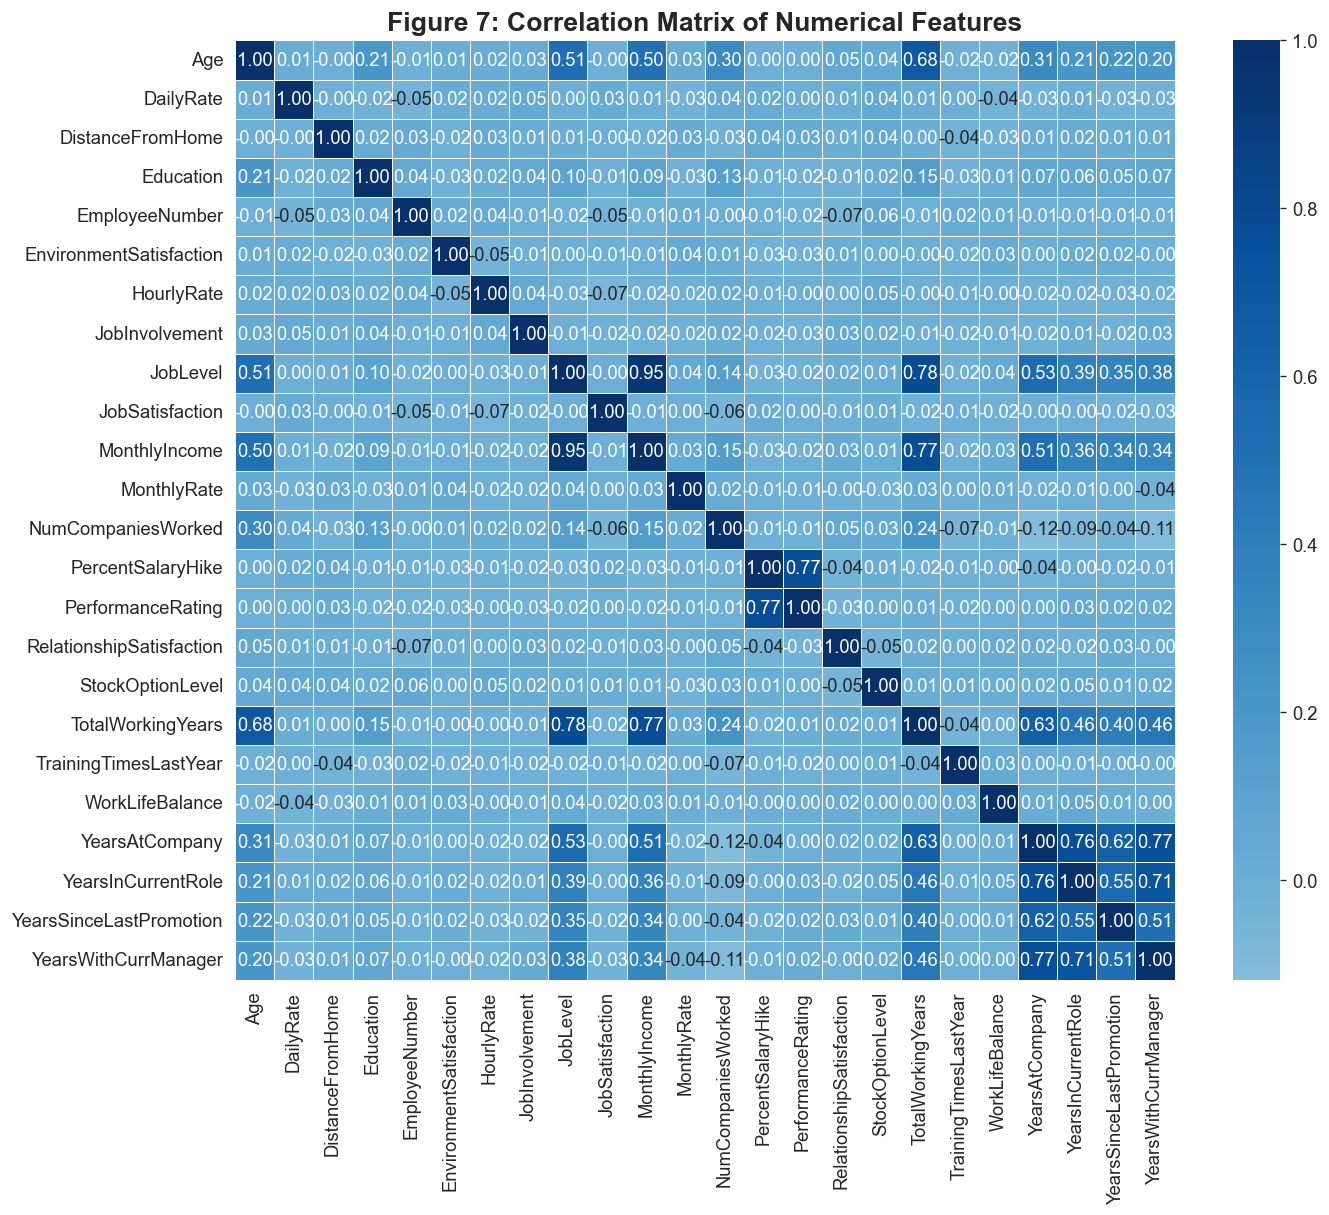

In [12]:
# ==========================================
# Figure 7 : Correlation Heatmap
# ==========================================

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="Blues",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Figure 7: Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## EDA Summary

Key findings:

- The target variable is moderately imbalanced.
- Employees working overtime appear more likely to leave.
- Monthly income shows noticeable differences between attrition groups.
- Some numerical features contain outliers.
- Strong correlations exist among years-related variables.
- Job role and department exhibit different attrition patterns.

## 4. Feature engineering — built BEFORE splitting X / y

This is the key correctness fix: every engineered column below is now part of the
feature matrix the models actually see.


In [13]:
#Domain inspired engineered features.. 
df["IncomePerYearExperience"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)
df["PromotionGap"]= df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["CareerStability"] = df["YearsWithCurrManager"] / (df["YearsAtCompany"] + 1)
df["TotalSatifaction"] = np.average(df["EnvironmentSatisfaction"] + df["JobSatisfaction"] + df["RelationshipSatisfaction"] +
df["WorkLifeBalance"])
df["ExperienceRatio"] = df["YearsAtCompany"] / df["Age"]



In [14]:
#X, Y split..
X = df.drop(columns="Attrition")

y = df["Attrition"].map({
    "No":0,
    "Yes":1
})

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Leak free preprocessing Pipeline...


In [16]:
#lead free preprocessing pipeline.. 
num_colsX = X_train.select_dtypes(include="number").columns

cat_colsX = X_train.select_dtypes(exclude="number").columns


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_colsX),
    ("cat", categorical_pipe, cat_colsX),
])

def build_pipeline(model):
    return Pipeline([("prep", preprocessor), ("model", model)])

print("Numeric:", num_colsX)
print("Categorical:", cat_colsX)

Numeric: Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'IncomePerYearExperience', 'PromotionGap', 'CareerStability',
       'TotalSatifaction', 'ExperienceRatio'],
      dtype='object')
Categorical: Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale", probability=True,
                               class_weight="balanced", random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=1000, class_weight="balanced",
                                                  n_jobs=-1, random_state=SEED),
    "XGBoost":             xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=5,
                                             subsample=0.9, colsample_bytree=0.9,
                                             tree_method="hist", eval_metric="mlogloss",
                                             n_jobs=-1, random_state=SEED),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=5,
                                              class_weight="balanced", n_jobs=-1,
                                              random_state=SEED, verbose=-1),
    "CatBoost":            CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=5,
                                              verbose=0, random_state=SEED),
}
print(f"{len(models)} models defined")

7 models defined


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "Accuracy":  "accuracy",
    "Precision": "precision_macro",
    "Recall":    "recall_macro",
    "F1":        "f1_macro",
    "AUC":       "roc_auc_ovr",
}

rows = []
for name, mdl in models.items():
    t0 = time.time()
    cvres = cross_validate(build_pipeline(mdl), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for label in scoring:
        m, s = cvres[f"test_{label}"].mean(), cvres[f"test_{label}"].std()
        row[label] = f"{m:.3f} ± {s:.3f}"
        row[f"_{label}"] = m          # numeric copy for sorting/plotting
    row["Time (s)"] = round(time.time() - t0, 2)
    rows.append(row)
    print(f"  done: {name}")

results_df = (pd.DataFrame(rows)
              .sort_values("_F1", ascending=False)
              .reset_index(drop=True))
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC", "Time (s)"]
print("\nTABLE I — 5-fold CV (mean ± std)")
display(results_df[display_cols])

  done: Logistic Regression
  done: KNN (k=7)
  done: SVM (RBF)
  done: Random Forest
  done: XGBoost
  done: LightGBM
  done: CatBoost

TABLE I — 5-fold CV (mean ± std)


,Model,Accuracy,Precision,Recall,F1,AUC,Time (s)
0,SVM (RBF),0.866 ± 0.007,0.765 ± 0.023,0.685 ± 0.023,0.711 ± 0.021,0.802 ± 0.042,2.79
1,XGBoost,0.878 ± 0.010,0.819 ± 0.024,0.670 ± 0.035,0.708 ± 0.038,0.807 ± 0.026,1.15
2,LightGBM,0.867 ± 0.012,0.787 ± 0.043,0.653 ± 0.019,0.686 ± 0.022,0.781 ± 0.017,2.91
3,CatBoost,0.873 ± 0.009,0.830 ± 0.041,0.646 ± 0.030,0.683 ± 0.032,0.813 ± 0.027,3.95
4,Logistic Regression,0.757 ± 0.020,0.654 ± 0.008,0.744 ± 0.011,0.666 ± 0.012,0.830 ± 0.025,3.46
5,Random Forest,0.861 ± 0.010,0.867 ± 0.079,0.581 ± 0.029,0.599 ± 0.043,0.809 ± 0.027,2.65
6,KNN (k=7),0.851 ± 0.009,0.795 ± 0.093,0.554 ± 0.026,0.558 ± 0.043,0.672 ± 0.064,2.77


In [19]:
best_name = results_df.iloc[0]["Model"]
print("Best model from CV:", best_name)

param_grids = {
    "Logistic Regression": {"model__C": [0.1, 0.5, 1, 2, 5]},
    "SVM (RBF)":           {"model__C": [1, 5, 10, 20], "model__gamma": ["scale", 0.01, 0.1]},
    "Random Forest":       {"model__n_estimators": [300, 500],
                            "model__max_depth": [None, 6, 10],
                            "model__min_samples_leaf": [1, 2, 4]},
    "KNN (k=7)":           {"model__n_neighbors": [3, 5, 7, 9, 11]},
    "XGBoost":             {"model__max_depth": [3, 4, 5], "model__learning_rate": [0.03, 0.05, 0.1]},
    "LightGBM":            {"model__max_depth": [3, 4, 5], "model__learning_rate": [0.03, 0.05, 0.1]},
    "CatBoost":            {"model__depth": [3, 4, 5], "model__learning_rate": [0.03, 0.05, 0.1]},
}

grid = param_grids.get(best_name, {})
best_pipe = build_pipeline(models[best_name])

if grid:
    search = GridSearchCV(best_pipe, grid, cv=cv, scoring="f1_macro", n_jobs=-1)
    search.fit(X, y)
    best_pipe = search.best_estimator_
    print("Best params:", search.best_params_)
    print(f"Tuned CV macro-F1: {search.best_score_:.4f}")
else:
    print("No grid defined; using default best pipeline.")

Best model from CV: SVM (RBF)
Best params: {'model__C': 1, 'model__gamma': 'scale'}
Tuned CV macro-F1: 0.7218


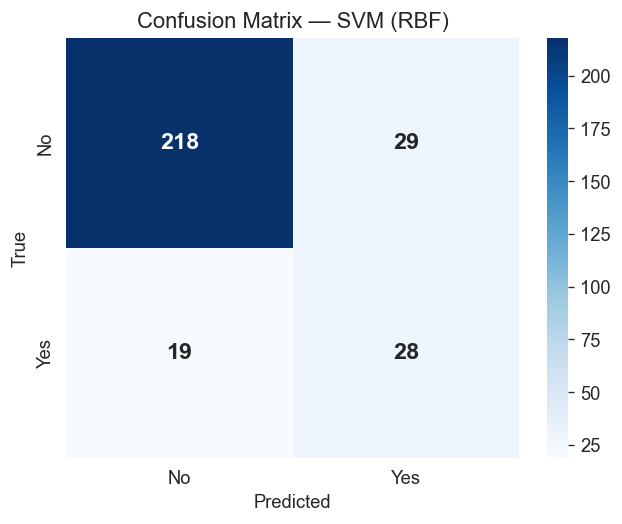

Classification report — SVM (RBF)
              precision    recall  f1-score   support

          No       0.92      0.88      0.90       247
         Yes       0.49      0.60      0.54        47

    accuracy                           0.84       294
   macro avg       0.71      0.74      0.72       294
weighted avg       0.85      0.84      0.84       294



In [20]:

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size":14,"fontweight":"bold"}
)
ax.set(xlabel="Predicted", ylabel="True",
       title=f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.savefig("fig_confusion.png", bbox_inches="tight"); plt.show()

print(f"Classification report — {best_name}")
labels = ["No", "Yes"]

print(classification_report(
    y_test,
    y_pred,
    target_names=labels
))

In [21]:
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
model = best_pipe.named_steps["model"]

if hasattr(model, "feature_importances_"):
    imp = pd.Series(model.feature_importances_, index=feat_names)
elif hasattr(model, "coef_"):
    imp = pd.Series(np.abs(model.coef_).mean(axis=0), index=feat_names)
else:
    imp = None

if imp is not None:
    imp = imp.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.sort_values().plot.barh(ax=ax, color="#2c3e50", edgecolor="white")
    ax.set_title(f"Top-15 Feature Importance — {best_name}", fontweight="bold")
    ax.set_xlabel("Importance")
    plt.tight_layout(); plt.savefig("fig_importance.png", bbox_inches="tight"); plt.show()
else:
    print(f"{best_name} exposes no importances/coefficients.")

SVM (RBF) exposes no importances/coefficients.


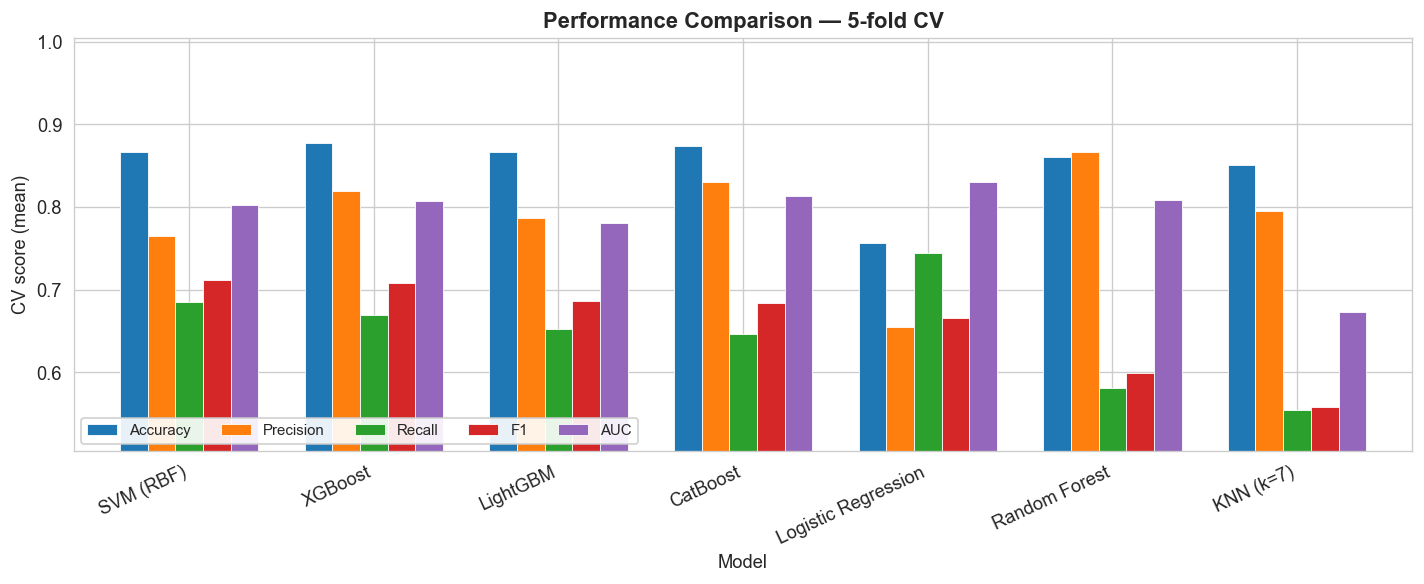

In [22]:
metric_cols = ["_Accuracy", "_Precision", "_Recall", "_F1", "_AUC"]
plot_df = results_df.set_index("Model")[metric_cols]
plot_df.columns = [c[1:] for c in metric_cols]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(max(0, plot_df.values.min() - 0.05), 1.005)
ax.set_ylabel("CV score (mean)")
ax.set_title("Performance Comparison — 5-fold CV", fontweight="bold")
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.savefig("fig_comparison.png", bbox_inches="tight"); plt.show()